# Task 5 - Movie Recommendation System

Recommending movies to users based on what similar users liked (user-based collaborative filtering).
Dataset: MovieLens small dataset from GroupLens (ml-latest-small, downloaded from Kaggle): 100,836 ratings from 610 users.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

In [2]:
ratings = pd.read_csv("ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
movies = pd.read_csv("movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Understanding the data
No missing values. Most ratings are between 3 and 5, with 4.0 the most common. Every user rated at least 20 movies.

In [4]:
print("Ratings:", len(ratings))
print("Users:", ratings["userId"].nunique())
print("Movies rated:", ratings["movieId"].nunique())
print("Missing values:", ratings.isnull().sum().sum())

Ratings: 100836
Users: 610
Movies rated: 9724
Missing values: 0


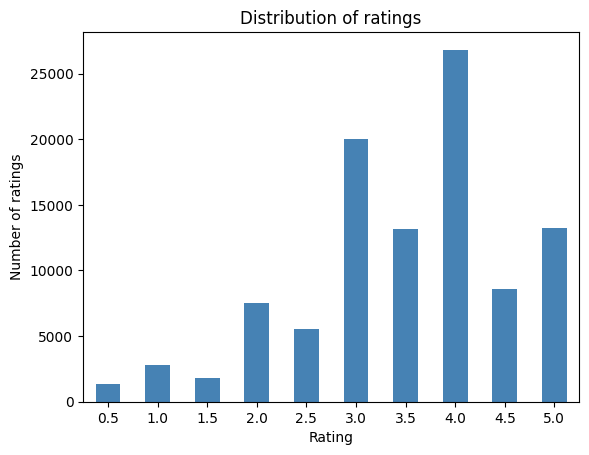

In [5]:
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue", rot=0)
plt.title("Distribution of ratings")
plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.show()

In [6]:
per_user = ratings.groupby("userId").size()
print(per_user.describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


## 3. Train/test split
I hid 20% of each user's ratings (stratified by user) so I can check later if the recommendations match movies the user really liked.

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(ratings, test_size=0.2, random_state=42,
                               stratify=ratings["userId"])

print("Training ratings:", len(train))
print("Hidden test ratings:", len(test))

Training ratings: 80668
Hidden test ratings: 20168


## 4. User-item matrix
One row per user and one column per movie. Movies a user has not rated are 0. About 98.5% of the matrix is empty.

In [8]:
matrix = train.pivot_table(index="userId", columns="movieId", values="rating").fillna(0)

print("Matrix shape:", matrix.shape)
print("Share of empty cells:", round((matrix == 0).sum().sum() / matrix.size, 4))
matrix.iloc[:5, :8]

Matrix shape: (610, 8977)
Share of empty cells: 0.9853


movieId,1,2,3,4,5,6,7,8
userId,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. User similarity
Cosine similarity between every pair of users, based on their ratings.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = pd.DataFrame(cosine_similarity(matrix),
                          index=matrix.index, columns=matrix.index)

print("Similarity matrix shape:", similarity.shape)

print("Users most similar to user 1:")
print(similarity[1].drop(1).sort_values(ascending=False).head(5).round(3))

Similarity matrix shape: (610, 610)
Users most similar to user 1:
userId
368    0.290
91     0.287
64     0.285
330    0.280
202    0.279
Name: 1, dtype: float64


## 6. Recommendations
For a user, I take the 30 most similar users, compute a weighted average of their ratings for each movie, remove movies the user has already seen, and return the top 10.

In [12]:
def recommend(user_id, k=10, n_neighbours=30):
    neighbours = similarity[user_id].drop(user_id).sort_values(ascending=False).head(n_neighbours)

    scores = matrix.loc[neighbours.index].T.dot(neighbours) / neighbours.sum()

    already_seen = matrix.loc[user_id] > 0
    scores = scores[~already_seen]

    return scores.sort_values(ascending=False).head(k)

In [13]:
top = recommend(1)
recs = movies.set_index("movieId").loc[top.index, ["title"]]
recs["score"] = top.round(2).values
recs

,title,score
movieId,,
296,Pulp Fiction (1994),3.20
110,Braveheart (1995),2.99
1968,"Breakfast Club, The (1985)",2.86
858,"Godfather, The (1972)",2.81
1200,Aliens (1986),2.79
457,"Fugitive, The (1993)",2.76
589,Terminator 2: Judgment Day (1991),2.68
32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),2.64
2918,Ferris Bueller's Day Off (1986),2.63


## 7. Evaluation - precision@10
For each user, precision@10 is the share of the 10 recommended movies that are in their hidden ratings with a rating of 4 or more. I compare it with a simple baseline that recommends the most popular movies to everyone.

In [14]:
def precision_at_k(recommend_fn, k=10):
    scores = []
    for user in matrix.index:
        liked = set(test[(test["userId"] == user) & (test["rating"] >= 4)]["movieId"])
        if len(liked) == 0:
            continue
        recommended = set(recommend_fn(user, k))
        scores.append(len(recommended & liked) / k)
    return np.mean(scores), len(scores)

def cf_movies(user, k):
    return recommend(user, k).index

popularity = train.groupby("movieId").size().sort_values(ascending=False)

def popular_movies(user, k):
    seen = set(matrix.columns[matrix.loc[user] > 0])
    return [m for m in popularity.index if m not in seen][:k]

cf_score, n_users = precision_at_k(cf_movies)
pop_score, _ = precision_at_k(popular_movies)

print(f"Users evaluated: {n_users}")
print(f"Collaborative filtering precision@10: {cf_score:.3f}")
print(f"Most-popular baseline precision@10:  {pop_score:.3f}")

Users evaluated: 599
Collaborative filtering precision@10: 0.194
Most-popular baseline precision@10:  0.122


## 8. Bonus - Matrix factorisation (SVD)
TruncatedSVD reduces the matrix to 20 hidden factors and uses them to predict scores for unseen movies.

In [15]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(matrix)
svd_scores = pd.DataFrame(user_factors @ svd.components_,
                          index=matrix.index, columns=matrix.columns)

def svd_movies(user, k):
    unseen = svd_scores.loc[user][matrix.loc[user] == 0]
    return unseen.sort_values(ascending=False).head(k).index

svd_score, _ = precision_at_k(svd_movies)
print(f"SVD precision@10: {svd_score:.3f}")

SVD precision@10: 0.197


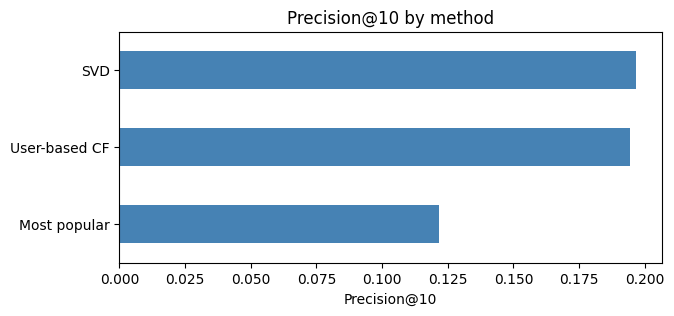

Most popular     0.122
User-based CF    0.194
SVD              0.197
dtype: float64


In [16]:
results = pd.Series({
    "Most popular": pop_score,
    "User-based CF": cf_score,
    "SVD": svd_score,
}).sort_values()

results.plot(kind="barh", color="steelblue", figsize=(7, 3))
plt.title("Precision@10 by method")
plt.xlabel("Precision@10")
plt.show()
print(results.round(3))

## Conclusion

The dataset has 100,836 ratings from 610 users on 9,724 movies, with no missing values.
The user-item matrix is about 98.5% empty, because each user has only rated a small part
of all the movies.

I hid 20% of each user's ratings and used the other 80% to build the recommender.
For user 1 it recommended movies like Pulp Fiction, The Godfather and Terminator 2,
which fits the kind of 80s and 90s films this user rated highly.

Results (precision@10, 599 users evaluated):
- Most popular movies: 0.122
- User-based collaborative filtering: 0.194
- SVD with 20 factors: 0.197

Both personalised methods did clearly better than just recommending the most popular movies,
so they learn something about each user's taste. SVD was slightly better than user-based
filtering.

A precision of about 0.2 means about 2 of every 10 recommended movies were in the user's
hidden list of liked movies. This underestimates the real quality, because a recommended
movie the user has not watched yet is not necessarily a bad recommendation.